In [ ]:
import requests, base64, os
import numpy as np
from io import BytesIO
from PIL import Image
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

load_dotenv()
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

ref = Image.open("INPUT/img03.jpg").convert("RGB")
buf = BytesIO()
ref.save(buf, format="JPEG", quality=95)
img_b64 = base64.b64encode(buf.getvalue()).decode()

def generate(img_b64, prompt):
    response = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers={"Authorization": f"Bearer {OPENROUTER_API_KEY}", "Content-Type": "application/json"},
        json={
            "model": "google/gemini-3.1-flash-image-preview",
            "messages": [{"role": "user", "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}},
                {"type": "text", "text": prompt},
            ]}],
            "modalities": ["image", "text"],
            "require": ["image"]
        },
        timeout=120,
    )
    data = response.json()
    images = data["choices"][0]["message"].get("images", [])
    if images:
        b64_data = images[0]["image_url"]["url"].split(",", 1)[-1]
        return Image.open(BytesIO(base64.b64decode(b64_data)))
    print("No image:", data)
    return None

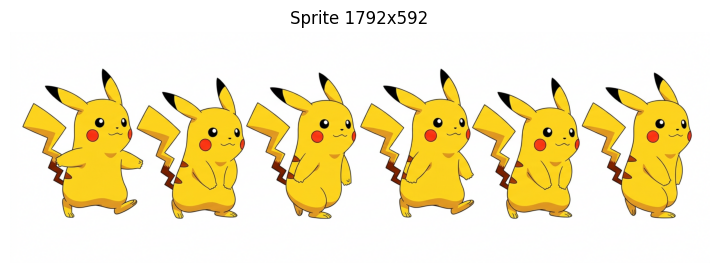

In [13]:
sprite = generate(img_b64,
    "Draw this character walking to the right: 6 poses in one horizontal row. "
    "Smooth walk cycle animation. Same character in every frame. "
    "Output a very wide horizontal image. "
    "Plain white background. No filmstrip borders, no decorations, no text."
)

sprite.save("OUTPUT/img03_walk_strip4.png")
plt.figure(figsize=(16, 3))
plt.imshow(sprite)
plt.axis("off")
plt.title(f"Sprite {sprite.size[0]}x{sprite.size[1]}")
plt.show()

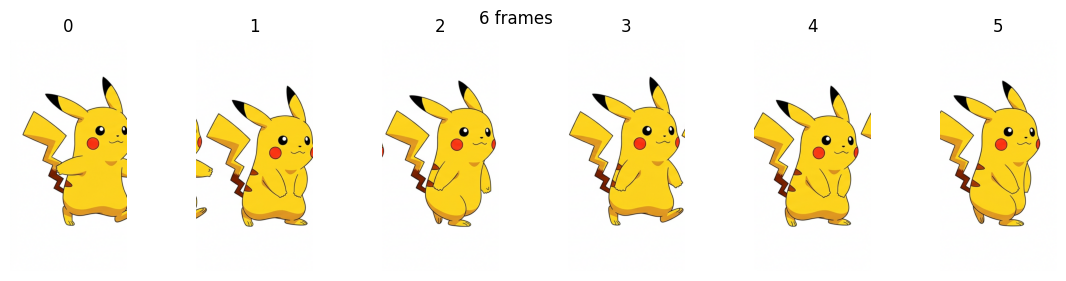

In [15]:
n = 6
w = sprite.size[0]
fw = w // n

frames = [sprite.crop((i * fw, 0, (i + 1) * fw, sprite.size[1])) for i in range(n)]

fig, axes = plt.subplots(1, n, figsize=(14, 3))
for i, (ax, f) in enumerate(zip(axes, frames)):
    ax.imshow(f); ax.set_title(f"{i}"); ax.axis("off")
plt.suptitle(f"{n} frames")
plt.show()


Saved: OUTPUT/img03_walk_i2i.gif


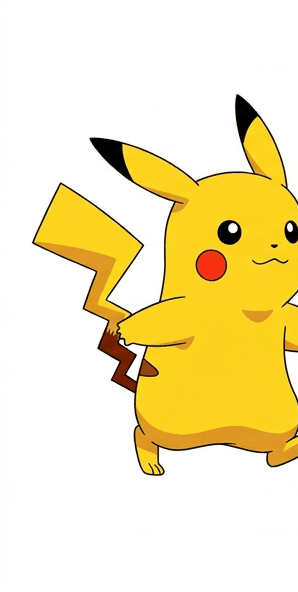

In [16]:
# Ресайзим под один размер + GIF
max_w = max(f.size[0] for f in frames)
max_h = max(f.size[1] for f in frames)

uniform = []
for f in frames:
    canvas = Image.new("RGB", (max_w, max_h), (255, 255, 255))
    canvas.paste(f, ((max_w - f.size[0]) // 2, (max_h - f.size[1]) // 2))
    uniform.append(canvas)

# Прямой + обратный порядок для плавного цикла
loop = uniform + uniform[-2:0:-1]

gif_path = "OUTPUT/img03_walk_i2i.gif"
loop[0].save(gif_path, save_all=True, append_images=loop[1:],
             duration=150, loop=0)
print(f"Saved: {gif_path}")
display(IPImage(filename=gif_path))
